In [ ]:
import pandas as pd
from glob import glob
from braceexpand import braceexpand
import numpy as np
import matplotlib.pyplot as plt
import pickle
import xarray as xr
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker

## Ici, on trace les POE des EETCs qui sont des compounds

C'est à dire que l'on fait le ranking avec le produit de deux métriques en amont, et on inclue dans le plot de chacune des métriques les ETCs qui sont des extrêmes dans les deux variables. C'est la suite logique du scatter plot des EETCs, une représentation de leur distribution sous forme de POE.

In [17]:
simulations = ['ERA5', 'UBB', 'UBD', 'UBE', 'UBF']
quantile = 0.99
ref = False #False #the ref parameter is useful to compare simulations with each other. If it is false, it might be better so set norm to True to compare simulations with a normalization.
norm = False #True #the norm parameter will normalize the metric values between 0 and 1. It is useful to compare simulations that do not share the same ref (each their own percentile)

In [18]:
EETC_dict_norm = {}
EETC_dict = {}
df = {}
sorted_EETC_cum_rank_sim = {}

for sim in simulations:
    (
        sorted_EETC_cum_rank,
        _,
        _,
        _,
        _,
        _,
        _,
        _,
        _,
        EETC_dict_norm_sim
    ) = calculate_ranking(sim=sim, quantile=quantile, ref=ref, method='product') #LA MÉTHODE N'A PAS D'INCIDENCE POUR LES PLOTS DE PDF !!! la méthode change le ranking des EETCs, pas la distinction EETC vs ETC

    sorted_EETC_cum_rank_sim[sim] = {
        "sorted_EETC_cum_rank": sorted_EETC_cum_rank,
    }
    
    df_sim, EETC_dict_sim = open_files(sim, ref=ref)

    EETC_dict_norm[sim] = EETC_dict_norm_sim
    EETC_dict[sim] = EETC_dict_sim
    df[sim] = df_sim

## We associate the date at which the pressure was minimum for each extreme ETCs of the dict, to later do a seasonal discrimation

In [19]:
for sim in simulations:
    EETCs = sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"]  #same as declaring EETCs before the loop in an array of dim == dim(sim), useful to get all EETCs index
    for storm in EETCs:
        storm_group = df[sim].groupby('storm').get_group(storm)
        min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
        if norm == True:
            EETC_dict_norm[sim][storm]['min_pressure_date'] = min_pressure_row['date']
        else:
            EETC_dict[sim][storm]['min_pressure_date'] = min_pressure_row['date']

In [56]:
plot_params = [
    {
        "var": "cum_precip",
        "label": '$EE_{PR,cum}|_{QC}$ [mm]',
        "ax_index": (0, 0)
    },
    {
        "var": "cum_avg_precip",
        "label": '$\overline{{EE}_{PR}|_{QC}}$ [mm.h$^{{-1}}$]',
        "ax_index": (0, 1)
    },
    # {
    #     "var": "SSI",
    #     "label": '$SSI$',
    #     "ax_index": (1, 0)
    # },
    {
        "var": "cum_wind",
        "label": '$EE_{WS,cum}|_{QC}$ [km]',
        "ax_index": (1, 0)
    },
    {
        "var": "cum_avg_wind",
        "label": '$\overline{{EE}_{WS}|_{QC}}$ [km.h$^{{-1}}$]',
        "ax_index": (1, 1)
    }
]

def clean_log_format(x, pos):
    if x >= 1 and x == int(x):
        return str(int(x))  # Affiche 1, 10, 100
    elif x < 1:
        return f"{x:.1g}"   # Par exemple : 0.1
    else:
        return str(x)

Text(0.5, 0.98, 'Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 or 2023 — $99.0^{th}$ percentile')

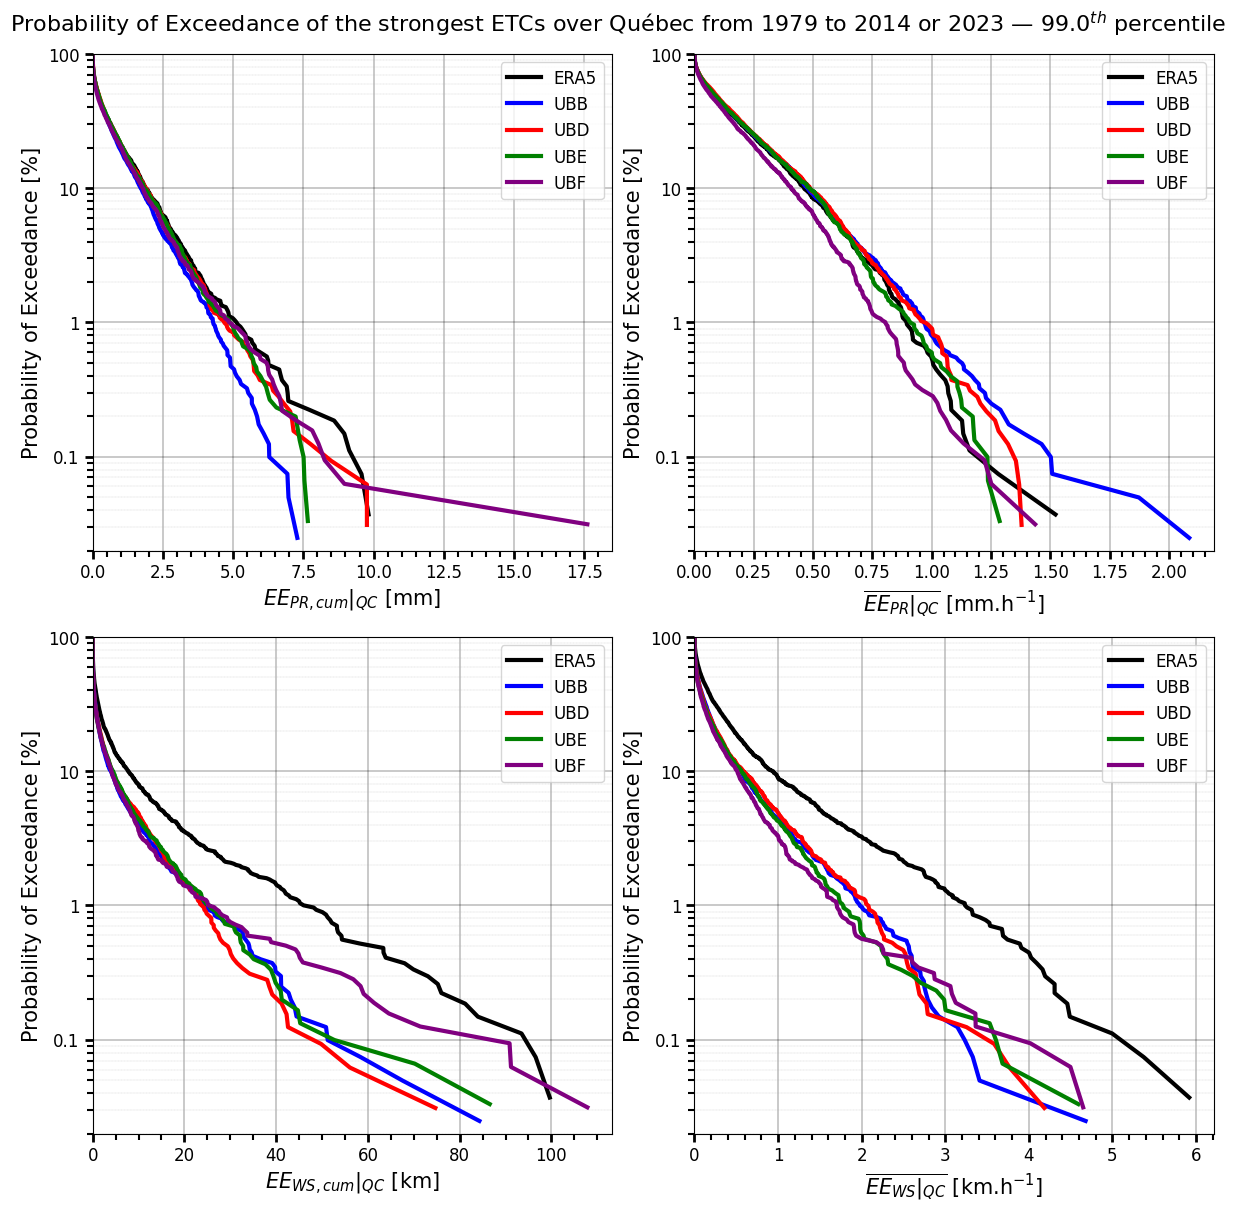

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

colors = ['k', 'blue', 'red', 'green', 'purple']

EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    for isim, sim in enumerate(simulations):
        if norm == True:
            EETCs_var = [EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
        else:    
            EETCs_var = [EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability
        
        ax.plot(sorted_vals, prob_exceedance * 100, color=colors[isim % len(colors)], linestyle='-', label=sim, linewidth=3)
        
    if norm == True:
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, None)
    # ax.set_ylim(-1.3, 2)  # Set y-axis limits to stop at 10^0
    ax.set_ylim(0.02, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 or 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'ERA5 Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2023 — $99.0^{th}$ percentile')

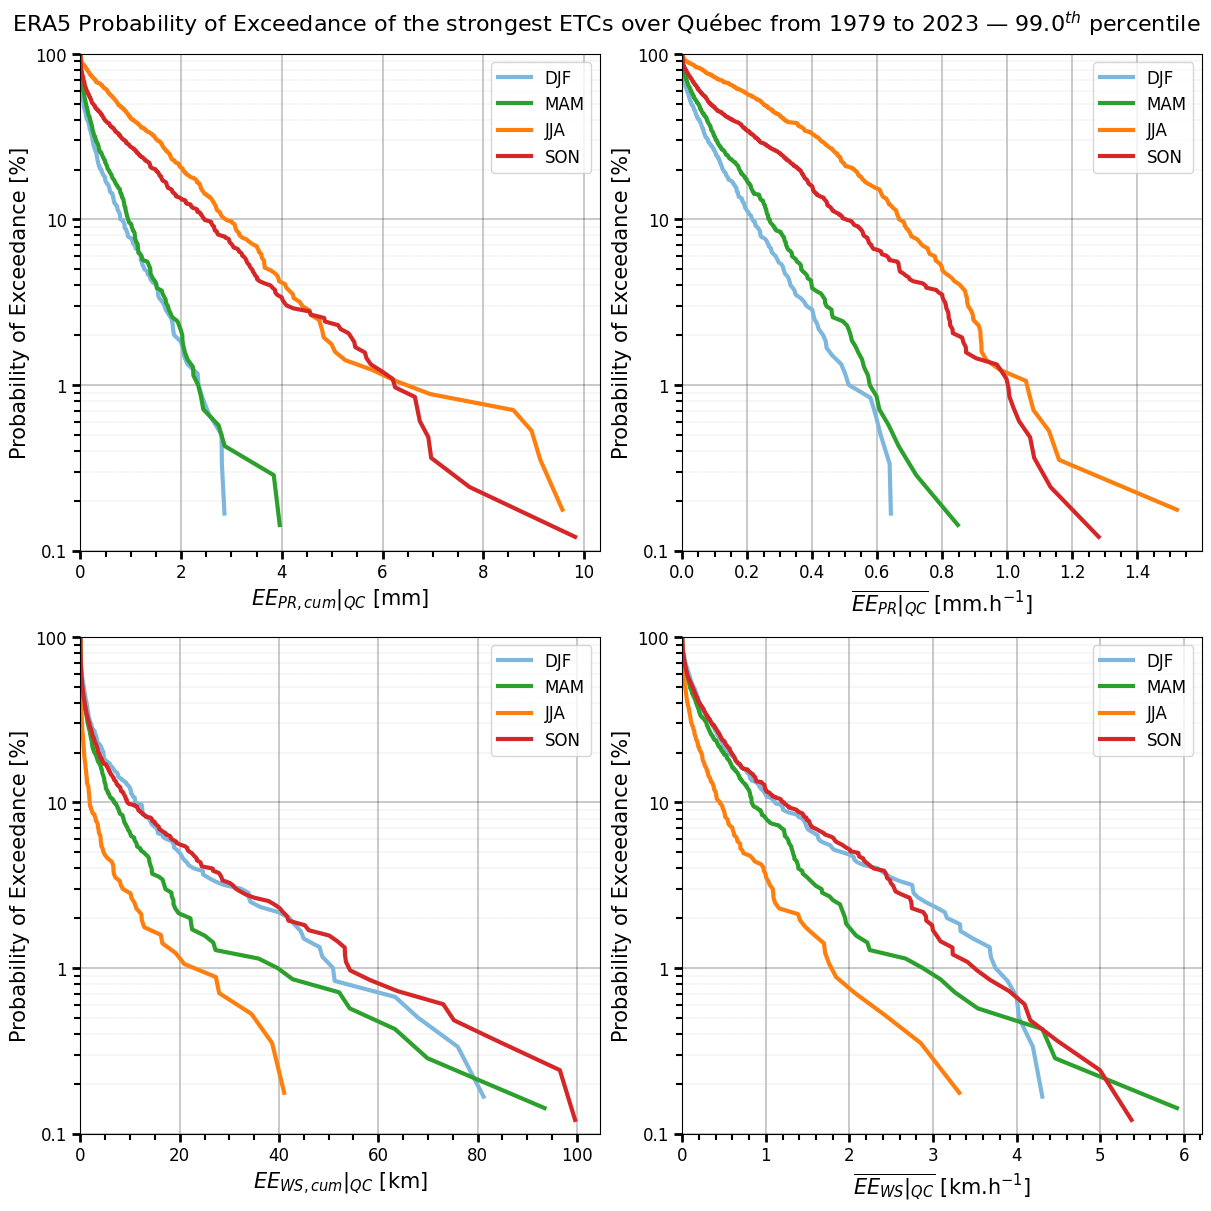

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[0]
    isim = 0
    
    for season, months in seasons.items():
        if norm == True:
            EETCs_var = [
                EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict_norm[sim][k]['min_pressure_date']).month in months
            ]
        else:
            EETCs_var = [
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            ]                
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
        
    if norm == True:
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'UBB Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2023 — $99.0^{th}$ percentile')

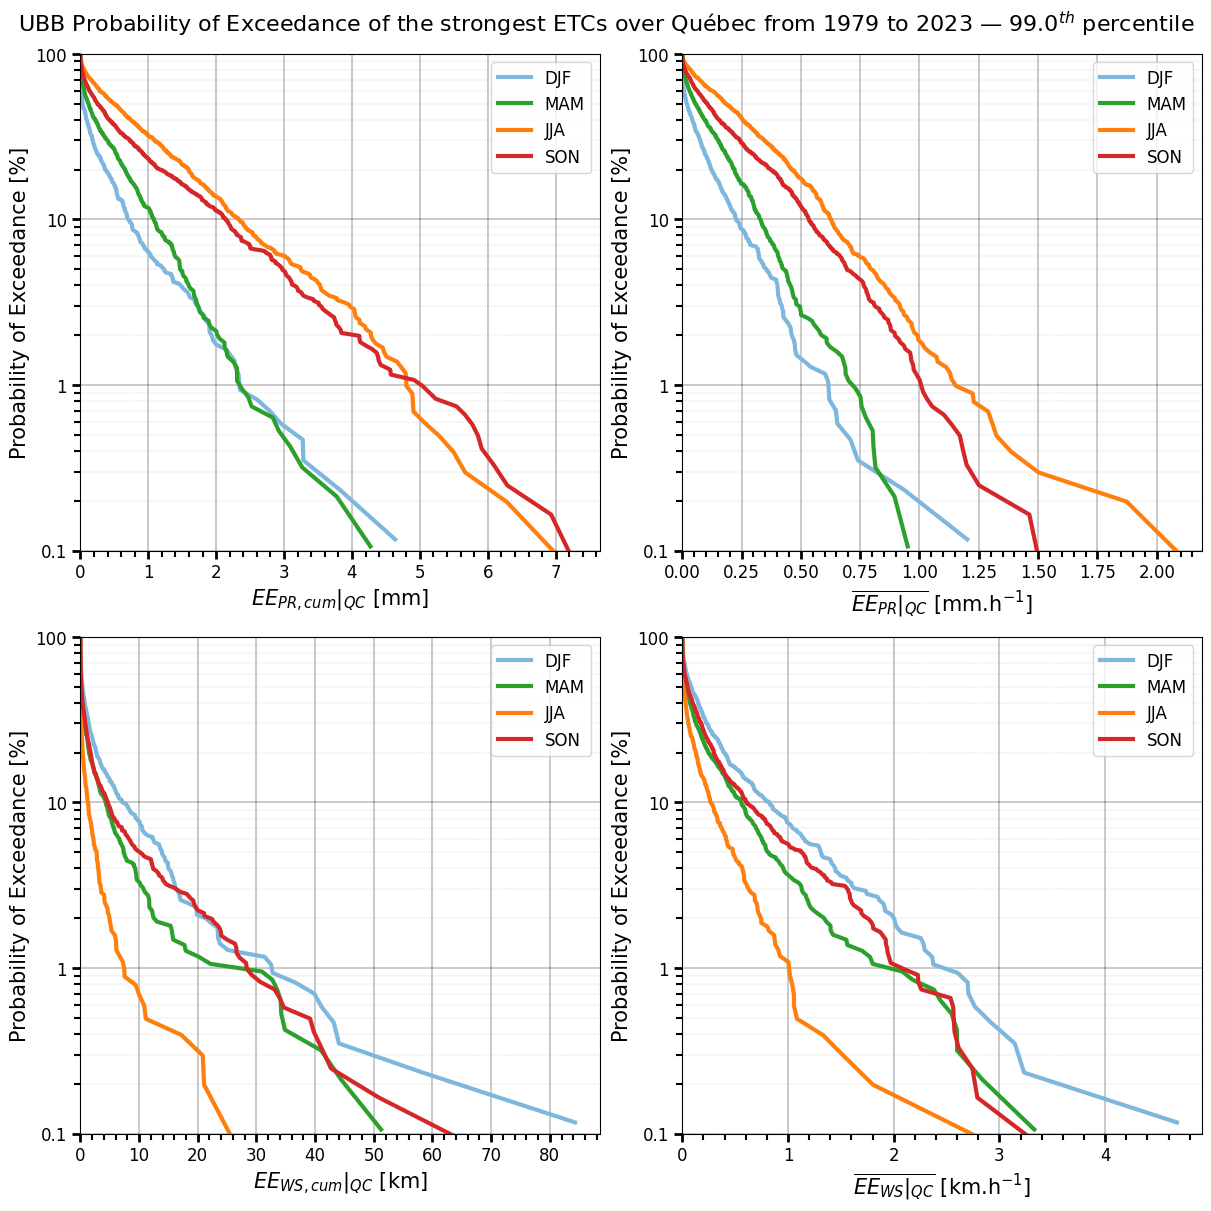

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[1]
    isim = 1
    
    for season, months in seasons.items():
        if norm == True:
            EETCs_var = [
                EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict_norm[sim][k]['min_pressure_date']).month in months
            ]
        else:
            EETCs_var = [
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            ]    
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
        
    if norm == True:
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'UBD Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 — $99.0^{th}$ percentile')

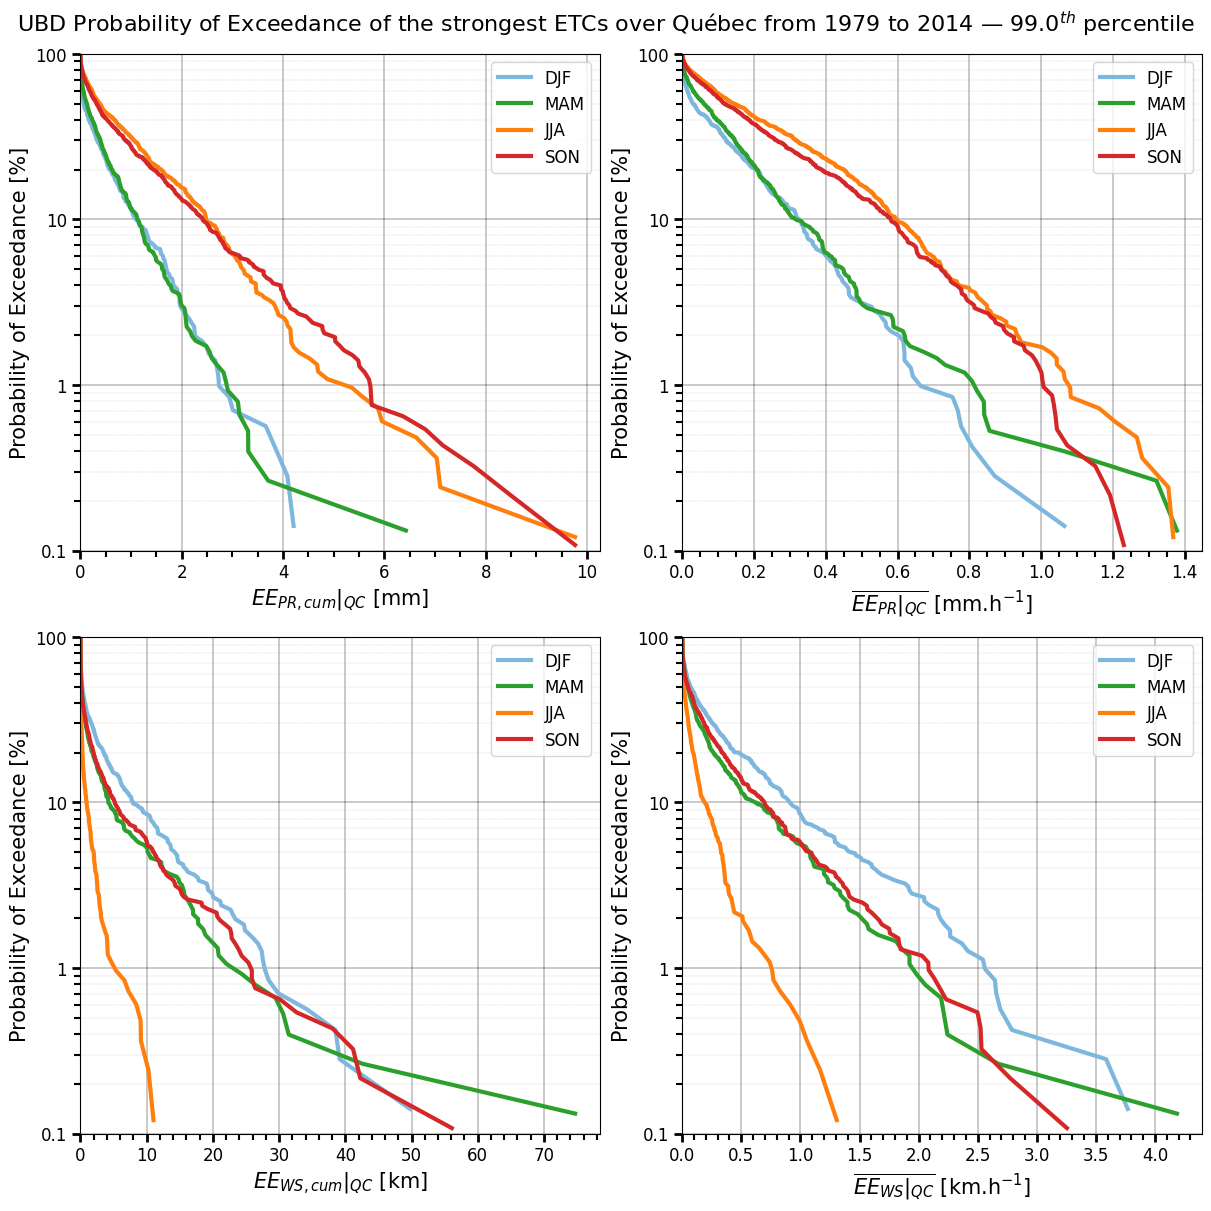

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[2]
    isim = 2
    
    for season, months in seasons.items():
        if norm == True:
            EETCs_var = [
                EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict_norm[sim][k]['min_pressure_date']).month in months
            ]
        else:
            EETCs_var = [
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            ]    
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
        
    if norm == True:
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'UBE Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 — $99.0^{th}$ percentile')

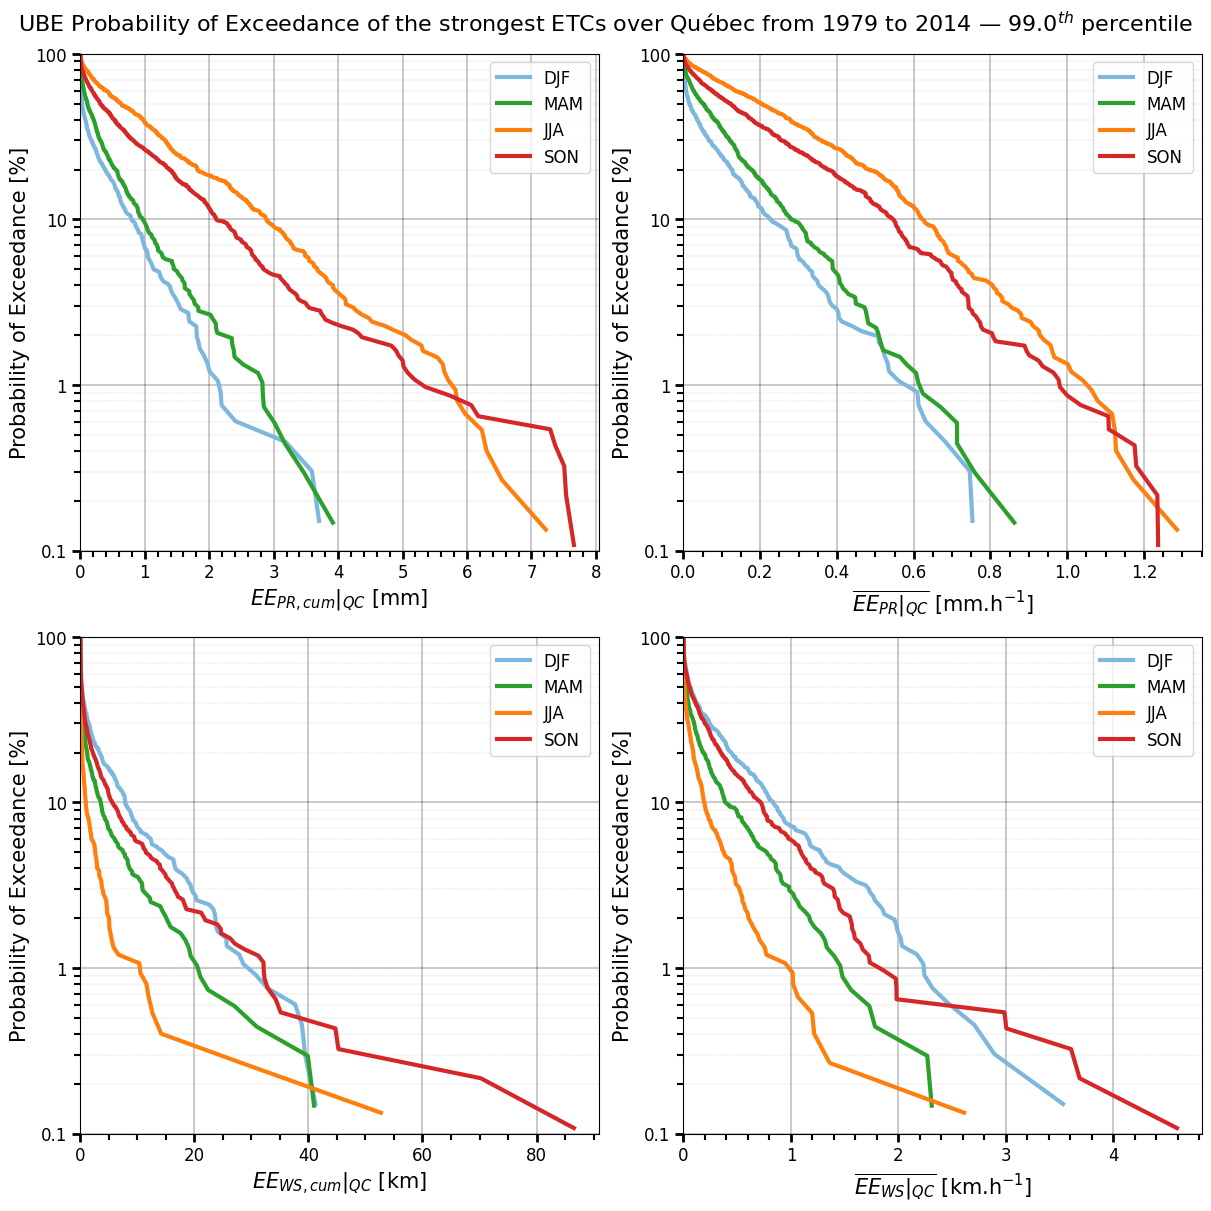

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[3]
    isim = 3
    
    for season, months in seasons.items():
        if norm == True:
            EETCs_var = [
                EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict_norm[sim][k]['min_pressure_date']).month in months
            ]
        else:
            EETCs_var = [
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            ]    
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
        
    if norm == True:
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

Text(0.5, 0.98, 'UBF Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 — $99.0^{th}$ percentile')

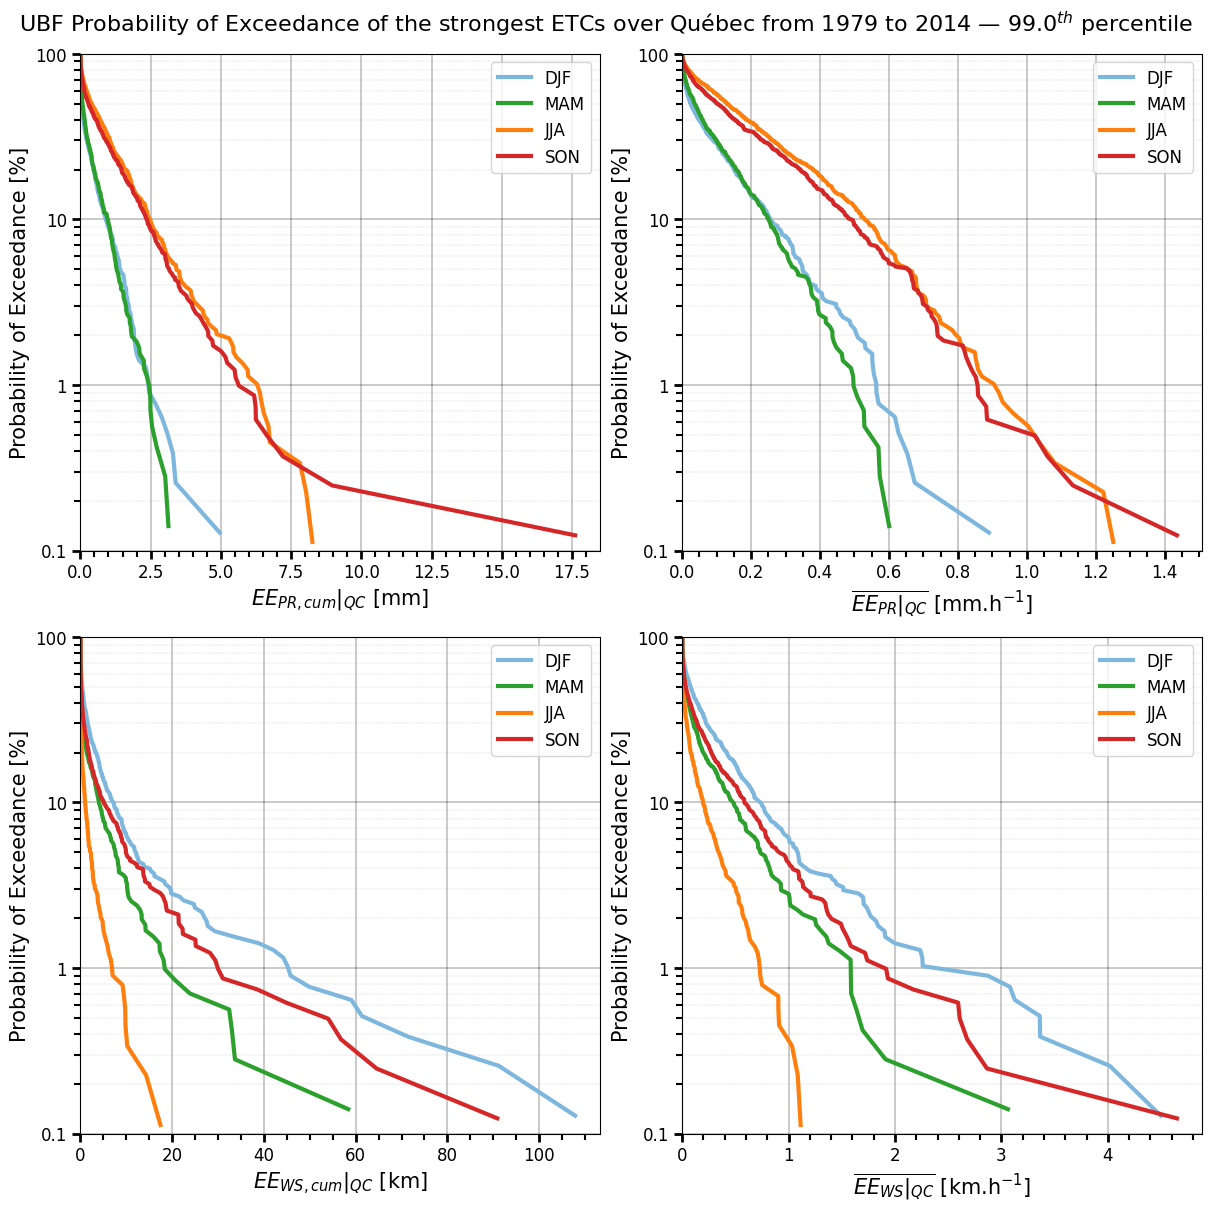

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[4]
    isim = 4
    
    for season, months in seasons.items():
        if norm == True:
            EETCs_var = [
                EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict_norm[sim][k]['min_pressure_date']).month in months
            ]
        else:
            EETCs_var = [
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
                for k in EETCs[isim]
                if pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            ]    
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
        
    if norm == True:
        ax.set_xlim(0, 1)
    else:
        ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1979 to 2014 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

In [27]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# colors = ['k', 'blue', 'red', 'green', 'purple']

# EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

# for params in plot_params:
#     ax = axes[params["ax_index"]]
    
#     for isim, sim in enumerate(simulations):
#         if norm == True:
#             EETCs_var = [EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]            
#         else:
#             EETCs_var = [EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
    
#         kde = gaussian_kde(EETCs_var)
#         vals = np.linspace(min(EETCs_var), max(EETCs_var), 1000)
#         density = kde(vals)
#         density /= density.max()  # Normalize density
#         ax.plot(vals, density, color=colors[isim % len(colors)], linestyle='-', label=sim, linewidth=3)
        
#     if norm == True:
#         ax.set_xlim(0, 1)
#     else:
#         ax.set_xlim(0, None)
#     # ax.set_ylim(0, 1)
#     ax.set_ylim(bottom=1e-3)
#     ax.set_yscale('log')
#     ax.set_xlabel("Metric value", fontsize=15)
#     ax.set_ylabel("Normalized Density", fontsize=15)
#     ax.set_title(params["label"], fontsize=15)
#     ax.legend(fontsize=12, loc='upper right')
#     ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
#     ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
#     ax.xaxis.set_minor_locator(AutoMinorLocator())
    

# fig.suptitle(f"PDF of the strongest ETCs over Québec from 1979 to 2014 or 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

In [28]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# colors = ['k', 'blue', 'red', 'green', 'purple']

# EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

# for params in plot_params:
#     ax = axes[params["ax_index"]]
    
#     for isim, sim in enumerate(simulations):
#         if norm == True:
#             EETCs_var = [EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
#         else:
#             EETCs_var = [EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
#         # Sort values for probability of exceedance
#         sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
#         prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability
        
#         ax.plot(sorted_vals, (1 - prob_exceedance) * 100, color=colors[isim % len(colors)], linestyle='-', label=sim, linewidth=3)
        
#     if norm == True:
#         ax.set_xlim(0, 1)
#     else:
#         ax.set_xlim(0, None)
#     ax.set_ylim(0, 100)
#     # ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
#     # ax.set_yscale('log')  # Set y-axis to logarithmic scale
#     ax.set_xlabel("Metric value", fontsize=15)
#     ax.set_ylabel("Cumulative Distribution Function (CDF) [%]", fontsize=15)
#     ax.set_title(params["label"], fontsize=15)
#     ax.legend(fontsize=12, loc='upper right')
#     ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
#     ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
#     ax.xaxis.set_minor_locator(AutoMinorLocator())
#     ax.minorticks_on()
#     ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
#     ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"Cumulative Distribution Function of the strongest ETCs over Québec from 1979 to 2014 or 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

In [29]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# colors = ['k', 'blue', 'red', 'green', 'purple']

# EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

# for params in plot_params:
#     ax = axes[params["ax_index"]]
    
#     for isim, sim in enumerate(simulations):
#         if norm:
#             EETCs_var = [EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
#         else:
#             EETCs_var = [EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]

#         # Histogramme binné
#         bins = np.arange(0, 1.0001, 0.01) if norm else np.arange(min(EETCs_var), max(EETCs_var) + 0.05, 0.01)
#         ax.hist(EETCs_var, bins=bins, color=colors[isim % len(colors)], alpha=0.5, label=sim, edgecolor='black', density=True)
        
#     if norm == True:
#         ax.set_xlim(0, 1)
#     else:
#         ax.set_xlim(0, None)
#     ax.set_yscale('log')
#     ax.set_xlabel("Metric value", fontsize=15)
#     ax.set_ylabel("Frequency", fontsize=15)
#     ax.set_title(params["label"], fontsize=15)
#     ax.legend(fontsize=12, loc='upper right')
#     ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
#     ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')


# fig.suptitle(f"Probability Distribution Function of the strongest ETCs over Québec from 1979 to 2014 or 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

In [30]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# colors = ['k', 'blue', 'red', 'green', 'purple']

# EETCs = [sorted_EETC_cum_rank_sim[sim]["sorted_EETC_cum_rank"] for sim in simulations]  # Random ranking --> we just need all ETCs, that are not dependent on the ranking method

# for params in plot_params:
#     ax = axes[params["ax_index"]]
    
#     data = []
#     labels = []

#     for isim, sim in enumerate(simulations):
#         if norm:
#             EETCs_var = [EETC_dict_norm[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]
#         else:
#             EETCs_var = [EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values for k in EETCs[isim]]

#         data.append(EETCs_var)
#         labels.append(sim)

#     parts = ax.violinplot(data, showmeans=False, showmedians=True, showextrema=True)

#     # Customiser les couleurs
#     for pc, color in zip(parts['bodies'], colors):
#         pc.set_facecolor(color)
#         pc.set_alpha(0.6)
#         pc.set_edgecolor('black')

#     # Ajouter les médianes en noir
#     if 'cmedians' in parts:
#         parts['cmedians'].set_color('black')
#         parts['cmedians'].set_linewidth(2)

#     if norm == True:
#         ax.set_ylim(0, 1)
#     else:
#         ax.set_ylim(0, None)
#     ax.set_xticks(np.arange(1, len(labels) + 1))
#     ax.set_xticklabels(labels, rotation=30, fontsize=12)
#     ax.set_xlabel("Simulation", fontsize=15)
#     ax.set_ylabel("Metric value", fontsize=15)
#     ax.set_title(params["label"], fontsize=15)
#     ax.tick_params(axis='y', which='major', labelsize=12)
#     ax.grid(True, axis='y', linestyle='--', linewidth=0.3)


# fig.suptitle(f"Violin plots of the strongest ETCs over Québec from 1979 to 2014 or 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)